### **Investigating Financial Exclusion Target Variable**

In [1]:
import pandas as pd

file_path = r"C:\Users\HP\Documents\Phase_5_Project\Kenya-financial-inclusion-risk\Data\Raw\finaccess_2021_microdata.xlsx"
excel_file = pd.ExcelFile(file_path)

print(excel_file.sheet_names)

df = pd.read_excel(file_path, sheet_name="Dataset")

# Check whether the column exists as the Target Variable
print('excluded_informal_new2022' in df.columns)

['Dataset', 'Variable Information', 'Variable Values']
True


##### **Meaning of Categories**

This Column contains 3 financial access groups:

- Formal: The respondent uses formal financial services such as banks, SACCOs, insurance, regulated MFIs, etc.

- Mobile-Only: The respondent only uses mobile money services (e.g. M-Pesa) but does not use broader formal financial products.

- Excluded: The respondent has no access to either formal financial services or mobile money services.

##### **Propose Binary Target Definition**

Machine learning classification models work best with a binary target. 

- 1 = Financially Included (Formal)

- 0 = Not Fully Formally Included (Mobile Only)

- 0 = Not Fully Formally Included (Excluded)

This setup allows the model to predict whether a person is formally financially included.

In [6]:
# Creating the Binary Target
df['target_formal'] = df['excluded_informal_new2022'].map({
    'Formal': 1,
    'mobileonly': 0,
    'excluded': 0
})

print(df['target_formal'].head())

0    1.0
1    0.0
2    NaN
3    0.0
4    0.0
Name: target_formal, dtype: float64


##### **Checking Class Balance**
This describes whether one class dominates the dataset.


In [4]:
# Counting the Classes
print(df['target_formal'].value_counts())

#Percentage Distribution of the Classes
class_proportion = df['target_formal'].value_counts(normalize=True) * 100
print("Target Variable Proportions (%)")
print(class_proportion)


1.0    9412
0.0    8045
Name: target_formal, dtype: int64
Target Variable Proportions (%)
1.0    53.915335
0.0    46.084665
Name: target_formal, dtype: float64


##### **Interpretation of Class Balance**

The target classes are relatively balanced:

Class 1 (Formally Included) makes up approximately 53.9% of the dataset.
Class 0 (Mobile-only or Excluded) makes up approximately 46.1% of the dataset.

Because the proportions are close, there is no severe class imbalance problem. This is advantageous for machine learning models since both classes are sufficiently represented, reducing the risk of model bias toward one class.

Therefore, advanced balancing techniques such as oversampling or undersampling may not be necessary at this stage.

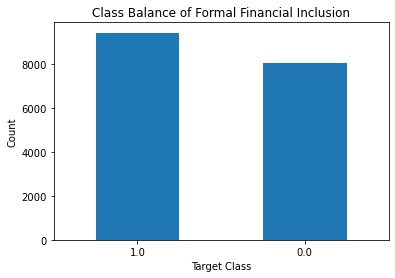

In [5]:
import matplotlib.pyplot as plt

# Plot class distribution
df['target_formal'].value_counts().plot(kind='bar')

plt.title('Class Balance of Formal Financial Inclusion')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.show()

##### **Interpretation**
- 1 represents Formal financial inclusion

- 0 represents Non-formal inclusion (mobile-only or excluded)

- The distribution indicates whether the dataset is balanced or imbalanced

- The bar chart shows that the two classes are relatively close in size, indicating that the dataset is fairly balanced. This is beneficial for classification modeling because the model can learn from both classes without major bias toward one class.


#### **Summary Of Deliverables**
- A binary Target Variable "target_formal" has been created from "excluded_informal_new2022 .

- Class distribution has been computed using value counts and percentage proportions, allowing assessment of dataset balance.

- Target Logic Explained using a Markdown Cell


In [13]:

# Clean the column first
df['excluded_informal_new2022'] = (
    df['excluded_informal_new2022']
    .str.strip()
    .str.lower()
)

# Create financially excluded target
df['financially_excluded'] = df['excluded_informal_new2022'].map({
    'excluded': 1,
    'formal': 0,
    'mobileonly': 0
})

# Preview
print(df[['excluded_informal_new2022', 'financially_excluded']].head())

  excluded_informal_new2022  financially_excluded
0                    formal                     0
1                mobileonly                     0
2                  excluded                     1
3                mobileonly                     0
4                mobileonly                     0


In [17]:
# Check missing values
print(df['financially_excluded'].isna().sum())

0


- The financially_excluded target variable contains 0 missing values, indicating that all records were successfully mapped into binary classes.

In [18]:
# Validation Steps Class Counts
print(df['financially_excluded'].value_counts())

0    17457
1     4567
Name: financially_excluded, dtype: int64


In [19]:
#Proportions Comparison
print(df['financially_excluded'].value_counts(normalize=True) * 100)

0    79.263531
1    20.736469
Name: financially_excluded, dtype: float64


In [20]:
# Confirmation of New created Column Existence
print('financially_excluded' in df.columns)

True
